# Semester Final Project

***🎯 Goal:*** Ask a question and answer it with a statistical investigation of your choosing.

Please make sure that you review [the rubric](https://docs.google.com/document/d/1PXHbL4Nvk_SqhOTZBWf4ZHdwnrugab7S6n3LZnxmxr0/edit?usp=sharing) before starting the project. When you are ready, fill out the sections below.

__________________________

## 🔎 My Question

How many numbers are typically called before a player gets a ‘bingo’ in a standard 5x5 bingo game?

## 📖 My Study 

My population is all possible bingo games using standard 5x5 cards (numbers 1-75 with a free space in the center). My variable is the amount of numbers called until a card achieves a bingo. The type of study I am conducting is a simulation-based observational study, meaning I will observe the outcomes generated randomly according to the game rules. I will ensure my data is random by making sure that each number has an equal probability of being called and every simulation is independent. 
I will simulate 1000 bingo games to create the random dataset.

A potential source of bias is that real bingo games have multiple players are playing at the same time and they all have different cards. My simulation assumes there's only a single player and a single card, which might not represent real-world bingo games. 


## 🗂️ My Data

*Collect your data using the cell below. When you are done with your collection, read the data into a dataframe and call `info()` on your dataframe.*

In [4]:
import numpy as np
import pandas as pd

np.random.seed(42)

def simulate_bingo():
    """
    Simulates a single bingo game and returns the number of calls
    until the card gets bingo.
    """
    card_numbers = np.arange(1, 76)
    np.random.shuffle(card_numbers)
    card = card_numbers[:24]  # exclude free center

    numbers_called = np.random.permutation(np.arange(1, 76))

    calls_needed = np.max([np.where(numbers_called == num)[0][0] for num in card]) + 1
    return calls_needed

num_simulations = 1000
calls_list = [simulate_bingo() for _ in range(num_simulations)]

df_bingo = pd.DataFrame({'calls_until_bingo': calls_list})

In [5]:
df_bingo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   calls_until_bingo  1000 non-null   int64
dtypes: int64(1)
memory usage: 7.9 KB


## 📊 My Analysis

*Perform your analysis in the cell below. Please feel free to add more cells if you need them!*

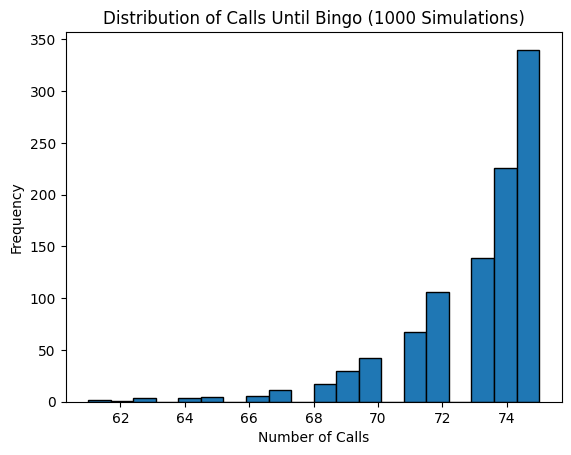

Mean calls until bingo: 73.08
Median calls until bingo: 74.0
Standard deviation: 2.32
25th percentile (Q1): 72.0
75th percentile (Q3): 75.0
IQR: 3.0
Number of outliers: 33
Outlier values: [63 67 67 61 67 64 63 62 67 67 66 63 65 67 66 67 64 65 66 66 67 63 61 64
 64 66 66 67 65 65 65 67 67]


In [6]:
import matplotlib.pyplot as plt

# 1. Histogram
plt.hist(df_bingo['calls_until_bingo'], bins=20, edgecolor='black')
plt.title("Distribution of Calls Until Bingo (1000 Simulations)")
plt.xlabel("Number of Calls")
plt.ylabel("Frequency")
plt.show()

# 2. Summary statistics
mean_calls = df_bingo['calls_until_bingo'].mean()
median_calls = df_bingo['calls_until_bingo'].median()
std_calls = df_bingo['calls_until_bingo'].std()
q1 = df_bingo['calls_until_bingo'].quantile(0.25)
q3 = df_bingo['calls_until_bingo'].quantile(0.75)
iqr = q3 - q1

print(f"Mean calls until bingo: {mean_calls:.2f}")
print(f"Median calls until bingo: {median_calls}")
print(f"Standard deviation: {std_calls:.2f}")
print(f"25th percentile (Q1): {q1}")
print(f"75th percentile (Q3): {q3}")
print(f"IQR: {iqr}")

# 3. Outlier detection using IQR method
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df_bingo[(df_bingo['calls_until_bingo'] < lower_bound) | 
                    (df_bingo['calls_until_bingo'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values: {outliers['calls_until_bingo'].values}")

## 🧠 My Answer

*Write your answer here.* <br>
My research question was "How many numbers are typically called before a player gets a bingo in a standard 5x5 bingo game?". The mean number of calls was 73.08, the median was 74 calls, the IQR was 3 calls (Q1 = 72, Q3 = 75) and the standard deviation was 2.32. 

This suggests that on average, a player achieves a bingo after about 73 calls and most games finish between 72 and 75 calls, which shows a small range of variability. The few outliers represent games where bingo occurs earlier than usual. 

The simulation demonstrates that, in a standard bingo game, bingo is most likely to occur near the end of the calling sequence, around 73-74 numbers. This shows that although the game is random, there is a predictable pattern for when games will typically end. 